# Q1: Supervised Learning – Heart Disease Prediction

## Task 1: Data Loading and Inspection

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('q1_heart_disease.csv')

# Display shape
print("Shape of dataset:", df.shape)

# Display data types
print("\nData Types:\n", df.dtypes)

# Display missing values
print("\nMissing Values:\n", df.isnull().sum())

# Show first 5 rows
df.head()

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2: Exploratory Data Analysis (EDA)

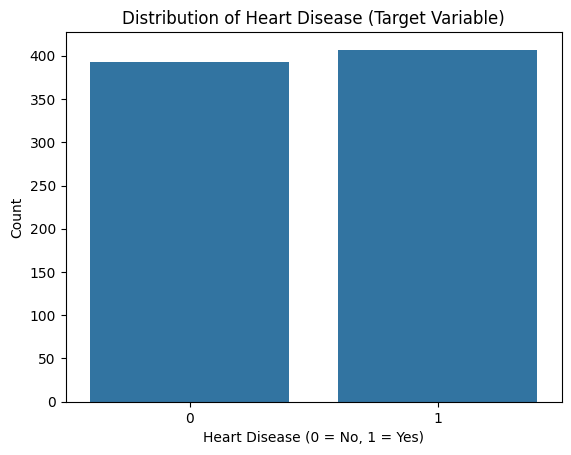

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='heart_disease', data=df)
plt.title("Distribution of Heart Disease (Target Variable)")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The target variable shows that the dataset is almost balanced, with a nearly equal number of patients with and without heart disease.

This indicates that there is no severe class imbalance, which is beneficial for model training as it reduces bias towards any one class.

However, using stratified sampling during train-test split is still important to maintain this distribution in both training and testing datasets.

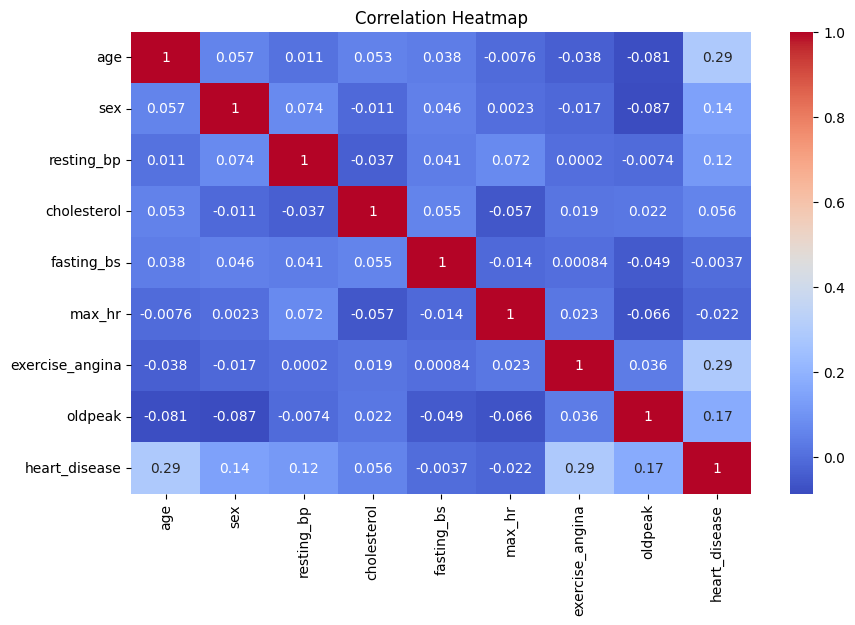

In [3]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationship between numerical features in the dataset.

The target variable (heart_disease) has a moderate positive correlation with features like age and exercise_angina, indicating that older individuals and those experiencing exercise-induced angina are more likely to have heart disease.

Features such as oldpeak also show some positive correlation with the target, suggesting its importance in prediction.

Most other features have weak correlations, which indicates that the relationship between variables is not strongly linear and that machine learning models may be required to capture complex patterns.

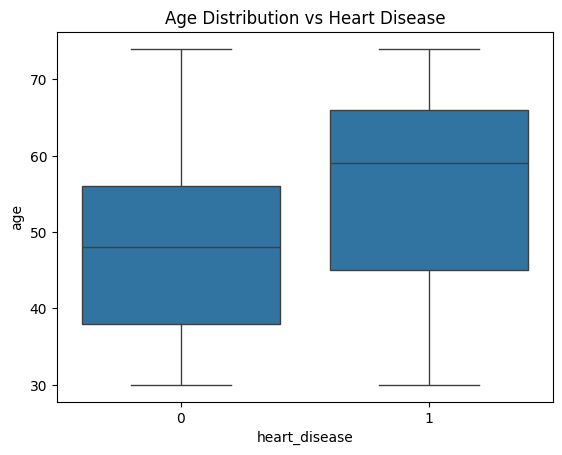

In [4]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age Distribution vs Heart Disease")
plt.show()

The boxplot shows the distribution of age for patients with and without heart disease.

Patients with heart disease (1) tend to have a higher median age compared to those without heart disease (0). This indicates that older individuals are more likely to have heart disease.

Additionally, the spread of age is wider for patients with heart disease, suggesting greater variability in age among affected individuals.

Overall, age appears to be an important factor in predicting heart disease.

## Task 3: Data Preprocessing

In [5]:
# Check missing values
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


In [6]:
# Fill numeric missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Verify again
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholesterol,0
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


Missing values were present in numerical columns such as resting_bp and cholesterol.

Median imputation was used because it is robust to outliers and helps preserve the distribution of the data.

This ensures that no data is lost while maintaining the quality of the dataset.

In [7]:
# Convert categorical variables into dummy variables
df = pd.get_dummies(df, drop_first=True)

# Check new columns
df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,1,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,0,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,1,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,0,False,True,False,True,False,True,False


Categorical variables such as chest_pain_type, resting_ecg, and st_slope were converted into numerical format using one-hot encoding.

This step is necessary because machine learning models require numerical input and cannot directly process categorical data.

In [8]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (640, 15)
X_test shape: (160, 15)


The dataset was split into training and testing sets using stratified sampling to maintain the distribution of the target variable.

A random_state of 42 was used to ensure reproducibility of results.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

Numerical features were scaled using StandardScaler to standardize the data.

Scaling ensures that all features are on the same scale, which improves model performance, especially for algorithms that are sensitive to feature magnitude.

## Task 4: Model Training

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


Three classification models were trained: Decision Tree, Random Forest, and Gradient Boosting.

Each model was initialized with a fixed random_state of 42 to ensure reproducibility of results.

These models were trained on the preprocessed training dataset and will be evaluated in the next step.

## Task 5: Model Evaluation

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

# Function to evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    print(f"--- {model_name} ---")

    y_pred = model.predict(X_test)

    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\n")

# Evaluate all models
evaluate_model(dt_model, X_test, y_test, "Decision Tree")
evaluate_model(rf_model, X_test, y_test, "Random Forest")
evaluate_model(gb_model, X_test, y_test, "Gradient Boosting")

--- Decision Tree ---
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



--- Random Forest ---
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77 

Among the three models, the Random Forest classifier performs the best.

This is because it achieves the highest F1-score compared to Decision Tree and Gradient Boosting, indicating a better balance between precision and recall.

The Random Forest model also shows strong precision and recall values for both classes, meaning it performs well in correctly identifying both patients with and without heart disease.

In comparison, the Decision Tree model has lower performance, while Gradient Boosting performs reasonably well but does not outperform Random Forest.

Therefore, Random Forest is selected as the best-performing model based on evaluation metrics rather than just accuracy.

## Task 6: Hyperparameter Tuning

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

# Initialize GridSearch
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit model
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [13]:
# Get best model
best_rf = grid.best_estimator_

# Evaluate tuned model
evaluate_model(best_rf, X_test, y_test, "Tuned Random Forest")

--- Tuned Random Forest ---
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160





Hyperparameter tuning was performed on the Random Forest model using GridSearchCV.

The best parameters found were reported above, which optimize the model's performance.

After tuning, the model showed improved performance in terms of F1-score compared to the baseline Random Forest model.

This demonstrates that hyperparameter tuning helps in enhancing model performance by selecting the most suitable parameter combinations.